# Unseen Object Instance Segmentation

In tabletop environments!

In [13]:
import sys, os
import json
from time import time
import glob
# sys.path.append('../')
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.io
import cv2
%matplotlib inline

# My libraries
import src.data_loader as data_loader
from uois_.src.ocid_data_inference import OCIDObject
import src.data_augmentation as data_augmentation
import src.segmentation as segmentation
import src.evaluation as evaluation
import src.util.utilities as util_
import src.util.flowlib as flowlib

os.environ['CUDA_VISIBLE_DEVICES'] = "0" # TODO: Change this if you have more than 1 GPU

In [2]:
def torch_to_numpy(torch_tensor, is_standardized_image = False):
    """ Converts torch tensor (NCHW) to numpy tensor (NHWC) for plotting
    
        If it's an rgb image, it puts it back in [0,255] range (and undoes ImageNet standardization)
    """
    np_tensor = torch_tensor.cpu().clone().detach().numpy()
    if np_tensor.ndim == 4: # NCHW
        np_tensor = np_tensor.transpose(0,2,3,1)
    if is_standardized_image:
        _mean=[0.485, 0.456, 0.406]; _std=[0.229, 0.224, 0.225]
        for i in range(3):
            np_tensor[...,i] *= _std[i]
            np_tensor[...,i] += _mean[i]
        np_tensor *= 255
            
    return np_tensor

## Depth Seeding Network parameters

In [3]:
dsn_params = {
    
    # Sizes
    'feature_dim' : 64,
    
    # algorithm parameters
    'lr' : 1e-2, # learning rate
    'iter_collect' : 20, # Collect results every _ iterations
    'max_iters' : 100000,
    
    # architecture parameters
    'use_coordconv' : False,

    # Loss function parameters
    'lambda_fg' : 1,
    'lambda_direction' : 1.,

    # Hough Voting parameters
    'skip_pixels' : 10, 
    'inlier_threshold' : 0.9, 
    'angle_discretization' : 100,
    'inlier_distance' : 20,
    'percentage_threshold' : 0.5, # this depends on skip_pixels, angle_discretization, inlier_distance. just gotta try it to see if it works
    'object_center_kernel_radius' : 10,

}

## Region Refinement Network parameters

In [4]:
rrn_params = {
    
    # Sizes
    'feature_dim' : 64,
    
    # algorithm parameters
    'lr' : 1e-2, # learning rate
    'iter_collect' : 20, # Collect results every _ iterations
    'max_iters' : 100000,
    
    # architecture parameters
    'use_coordconv' : False,
    
}

# Tabletop Segmentor parameters

In [5]:
tts_params = {
    
    # Padding for Region Refinement Network
    'padding_percentage' : 0.25,
    
    # Open/Close Morphology for IMP (Initial Mask Processing) module
    'use_open_close_morphology' : True,
    'open_close_morphology_ksize' : 9,
    
    # Closest Connected Component for IMP module
    'use_closest_connected_component' : True,
    
}
checkpoint_dir = 'uois2D_checkpoints/' # TODO: change this to directory of downloaded models
dsn_filename = checkpoint_dir + 'DepthSeedingNetwork_TOD_checkpoint.pth'
rrn_filename = checkpoint_dir + 'RRN_TOD_checkpoint.pth'
tts_params['final_close_morphology'] = 'TOD' in rrn_filename
tabletop_segmentor = segmentation.TableTopSegmentor(tts_params, 
                                                    dsn_filename,
                                                    dsn_params,
                                                    rrn_filename,
                                                    rrn_params
                                                   )

Let's use 1 GPUs!
Loaded DSN model
Let's use 1 GPUs!
Loaded RRN model


## Run on example images

We provided some example RGB-D images of scenarios in our lab environments. The following code loads those images and runs the network on them.

In [6]:
example_images_dir = os.path.abspath('.') + '/example_images/'
image_files = sorted(glob.glob(example_images_dir + '/image_*.npy'))
N = len(image_files)

camera_params = json.load(open(example_images_dir + 'camera_params.json'))

rgb_imgs = np.zeros((N, 480, 640, 3), dtype=np.float32)
xyz_imgs = np.zeros((N, 480, 640, 3), dtype=np.float32)
for i, img_file in enumerate(image_files):
    d = np.load(img_file, allow_pickle=True, encoding='bytes').item()
    
    # RGB
    rgb_img = d['rgb']
    rgb_imgs[i] = data_augmentation.standardize_image(rgb_img)

    # Depth
    depth_img = d['depth']
    depth_img = (depth_img / 1000.).astype(np.float32) # millimeters -> meters

    # Compute xyz ordered point cloud
    xyz_img = data_loader.compute_xyz(depth_img,camera_params)
    xyz_imgs[i] = xyz_img
    
batch = {
    'rgb' : data_augmentation.array_to_tensor(rgb_imgs),
    'xyz' : data_augmentation.array_to_tensor(xyz_imgs),
}

In [7]:
print("Number of images: {0}".format(N))

### Compute segmentation masks ###
st_time = time()
fg_masks, direction_predictions, initial_masks, seg_masks = tabletop_segmentor.run_on_batch(batch)
total_time = time() - st_time
print('Total time taken for Segmentation: {0} seconds'.format(round(total_time, 3)))
print('FPS: {0}'.format(round(N / total_time,3)))

# Get results in numpy
seg_masks = seg_masks.cpu().numpy()
fg_masks = fg_masks.cpu().numpy()
direction_predictions = direction_predictions.cpu().numpy().transpose(0,2,3,1)
initial_masks = initial_masks.cpu().numpy()

Number of images: 9


/home/ubuntu/anaconda3/envs/uois/lib/python3.7/site-packages/torch/nn/functional.py:2506: UserWarning: Default upsampling behavior when mode=bilinear is changed to align_corners=False since 0.4.0. Please specify align_corners=True if the old behavior is desired. See the documentation of nn.Upsample for details.
  "See the documentation of nn.Upsample for details.".format(mode))
/home/ubuntu/anaconda3/envs/uois/lib/python3.7/site-packages/torch/nn/functional.py:2589: UserWarning: nn.functional.upsample_bilinear is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample_bilinear is deprecated. Use nn.functional.interpolate instead.")
/home/ubuntu/anaconda3/envs/uois/lib/python3.7/site-packages/torch/nn/functional.py:2566: UserWarning: nn.functional.upsample_nearest is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample_nearest is deprecated. Use nn.functional.interpolate instead.")


Total time taken for Segmentation: 2.355 seconds
FPS: 3.821


In [9]:
rgb_imgs = torch_to_numpy(batch['rgb'].cpu(), is_standardized_image=True)
total_subplots = 6

fig_index = 1
for i in range(N):
    
    fig = plt.figure(fig_index); fig_index += 1
    fig.set_size_inches(20,5)

    # Plot image
    plt.subplot(1,total_subplots,1)
    plt.imshow(rgb_imgs[i,...].astype(np.uint8))
    plt.title('Image {0}'.format(i+1))

    # Plot Depth
    plt.subplot(1,total_subplots,2)
    plt.imshow(xyz_imgs[i,...,2])
    plt.title('Depth')
    
    # Plot initial table mask
    plt.subplot(1,total_subplots,3)
    plt.imshow(util_.get_color_mask(fg_masks[i,...]))
    plt.title("Foreground Table Mask")
    
    # Plot direction predictions
    plt.subplot(1,total_subplots,4)
    plt.imshow(flowlib.flow_to_image(direction_predictions[i,...]))
    plt.title("Center Direction Predictions")
    
    # Plot initial masks
    plt.subplot(1,total_subplots,5)
    plt.imshow(util_.get_color_mask(initial_masks[i,...]))
    plt.title(f"Initial Masks. #objects: {np.unique(initial_masks[i,...]).shape[0]-1}")
    
    # Plot Masks
    plt.subplot(1,total_subplots,6)
    plt.imshow(util_.get_color_mask(seg_masks[i,...]))
    plt.title(f"Refined Masks. #objects: {np.unique(seg_masks[i,...]).shape[0]-1}")   

/home/ubuntu/anaconda3/envs/uois/lib/python3.7/site-packages/matplotlib/figure.py:98: MatplotlibDeprecationWarning: 
Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  "Adding an axes using the same arguments as a previous axes "


## Run on example OSD/OCID images

We provide a few [OSD](https://www.acin.tuwien.ac.at/en/vision-for-robotics/software-tools/osd/) and [OCID](https://www.acin.tuwien.ac.at/en/vision-for-robotics/software-tools/object-clutter-indoor-dataset/) images and run the network on them. Evaluation metrics are shown for each of the images.

In [10]:
example_images_dir = os.path.abspath('.') + '/example_images/'

OSD_image_files = sorted(glob.glob(example_images_dir + '/OSD_*.npy'))
OCID_image_files = sorted(glob.glob(example_images_dir + '/OCID_*.npy'))
N = len(OSD_image_files) + len(OCID_image_files)

rgb_imgs = np.zeros((N, 480, 640, 3), dtype=np.float32)
xyz_imgs = np.zeros((N, 480, 640, 3), dtype=np.float32)
label_imgs = np.zeros((N, 480, 640), dtype=np.uint8)

for i, img_file in enumerate(OSD_image_files + OCID_image_files):
    d = np.load(img_file, allow_pickle=True, encoding='bytes').item()
    
    # RGB
    rgb_img = d['rgb']
    rgb_imgs[i] = data_augmentation.standardize_image(rgb_img)

    # XYZ
    xyz_imgs[i] = d['xyz']

    # Label
    label_imgs[i] = d['label']
    
batch = {
    'rgb' : data_augmentation.array_to_tensor(rgb_imgs),
    'xyz' : data_augmentation.array_to_tensor(xyz_imgs),
}

In [11]:
print("Number of images: {0}".format(N))

### Compute segmentation masks ###
st_time = time()
fg_masks, direction_predictions, initial_masks, seg_masks = tabletop_segmentor.run_on_batch(batch)
total_time = time() - st_time
print('Total time taken for Segmentation: {0} seconds'.format(round(total_time, 3)))
print('FPS: {0}'.format(round(N / total_time,3)))

# Get results in numpy
seg_masks = seg_masks.cpu().numpy()
fg_masks = fg_masks.cpu().numpy()
direction_predictions = direction_predictions.cpu().numpy().transpose(0,2,3,1)
initial_masks = initial_masks.cpu().numpy()

Number of images: 4
Total time taken for Segmentation: 1.181 seconds
FPS: 3.388


Image 1 Metrics:
{'Objects F-measure': 0.9588529146634615, 'Objects Precision': 0.9852379298367488, 'Objects Recall': 0.9338442404067747, 'Boundary F-measure': 0.9069536596834022, 'Boundary Precision': 0.9288389513108615, 'Boundary Recall': 0.8860759493670886, 'obj_detected': 7, 'obj_detected_075': 7, 'obj_gt': 7, 'obj_detected_075_percentage': 1.0}
Image 2 Metrics:
{'Objects F-measure': 0.8053701231271324, 'Objects Precision': 0.8628417037507946, 'Objects Recall': 0.7550764951321279, 'Boundary F-measure': 0.5396409898408288, 'Boundary Precision': 0.650985054347826, 'Boundary Recall': 0.4608222490931076, 'obj_detected': 15, 'obj_detected_075': 9, 'obj_gt': 16, 'obj_detected_075_percentage': 0.5625}
Image 3 Metrics:
{'Objects F-measure': 0.7523851438545714, 'Objects Precision': 0.9164455751408322, 'Objects Recall': 0.6381454908957471, 'Boundary F-measure': 0.67064681577962, 'Boundary Precision': 0.868474923234391, 'Boundary Recall': 0.5462236578987848, 'obj_detected': 12, 'obj_detected_

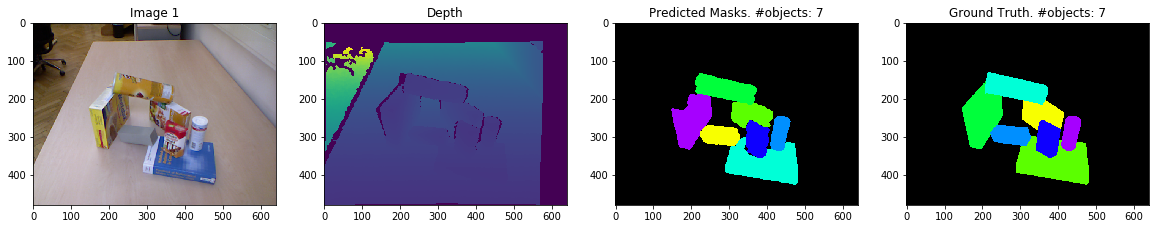

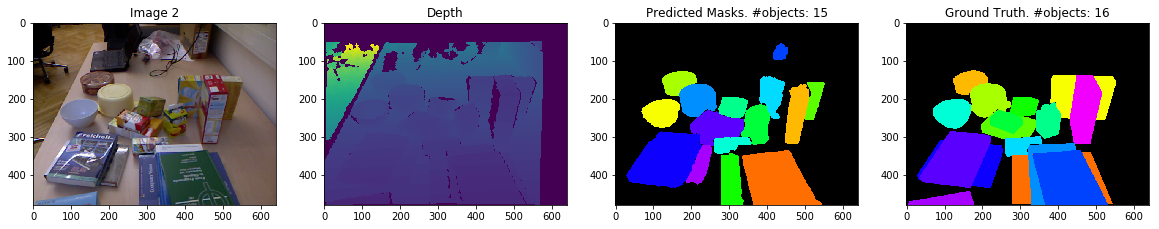

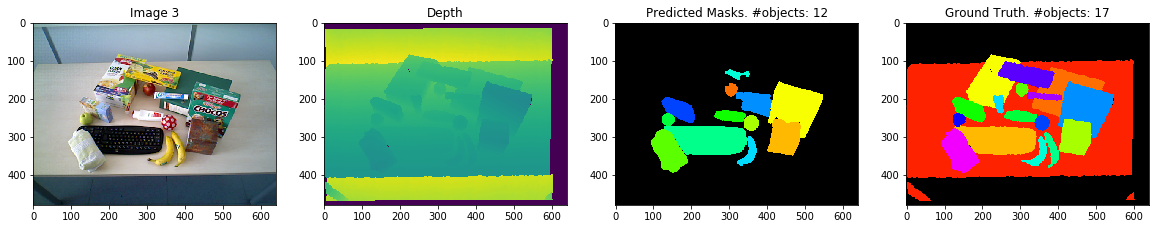

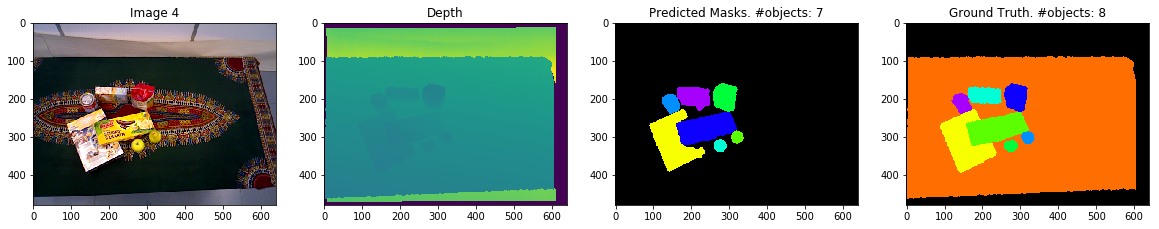

In [14]:
rgb_imgs = torch_to_numpy(batch['rgb'].cpu(), is_standardized_image=True)
total_subplots = 4

fig_index = 1
for i in range(N):
    
    fig = plt.figure(fig_index); fig_index += 1
    fig.set_size_inches(20,5)

    # Plot image
    plt.subplot(1,total_subplots,1)
    plt.imshow(rgb_imgs[i,...].astype(np.uint8))
    plt.title(f"Image {i+1}")

    # Plot Depth
    plt.subplot(1,total_subplots,2)
    plt.imshow(xyz_imgs[i,...,2])
    plt.title('Depth')
    
    num_objs = max(np.unique(seg_masks[i,...]).max(), np.unique(label_imgs[i,...]).max()) + 1
    
    # Plot Predicted Masks
    plt.subplot(1,total_subplots,3)
    plt.imshow(util_.get_color_mask(seg_masks[i,...], nc=num_objs))
    plt.title(f"Predicted Masks. #objects: {np.unique(seg_masks[i,...]).shape[0]-1}")
    
    # Plot GT Masks
    plt.subplot(1,total_subplots,4)
    plt.imshow(util_.get_color_mask(label_imgs[i,...], nc=num_objs))
    plt.title(f"Ground Truth. #objects: {np.unique(label_imgs[i,...]).shape[0]-1}")
    
    # Run evaluation metric
    eval_metrics = evaluation.multilabel_metrics(seg_masks[i,...], label_imgs[i])
    print(f"Image {i+1} Metrics:")
    print(eval_metrics)

Note: table label is not considered in evaluation metrics.

In [15]:
import random


In [16]:
ds = OCIDObject('all')

2390 images for dataset ocid_data_all


In [17]:
K = random.sample(range(0, 2390), 10)
N=len(K)
rgb_imgs = np.zeros((N, 480, 640, 3), dtype=np.float32)
xyz_imgs = np.zeros((N, 480, 640, 3), dtype=np.float32)
label_imgs = np.zeros((N, 480, 640), dtype=np.uint8)

for i in range(N):
    
    d = ds.__getitem__(K[i])
    rgb = d['rgb']
   
 
    rgb_imgs[i]= rgb
  
    xyz = d['xyz']
    xyz_imgs[i] = xyz
    
    label_imgs[i] = d['label']

batch={'rgb':data_augmentation.array_to_tensor(rgb_imgs),
      'xyz':data_augmentation.array_to_tensor(xyz_imgs)
      }
    

In [18]:
# rgb_imgs = util_.torch_to_numpy(batch['rgb'].cpu(), is_standardized_image=True)
# xyz_imgs = util_.torch_to_numpy(batch['xyz'].cpu())
print("Number of images: {0}".format(N))

### Compute segmentation masks ###
st_time = time()
fg_masks, direction_predictions, initial_masks, seg_masks = tabletop_segmentor.run_on_batch(batch)
total_time = time() - st_time
print('Total time taken for Segmentation: {0} seconds'.format(round(total_time, 3)))
print('FPS: {0}'.format(round(N / total_time,3)))

# Get results in numpy
seg_masks = seg_masks.cpu().numpy()
fg_masks = fg_masks.cpu().numpy()
direction_predictions = direction_predictions.cpu().numpy().transpose(0,2,3,1)
initial_masks = initial_masks.cpu().numpy()

Number of images: 10


/home/ubuntu/anaconda3/envs/uois/lib/python3.7/site-packages/torch/nn/functional.py:2506: UserWarning: Default upsampling behavior when mode=bilinear is changed to align_corners=False since 0.4.0. Please specify align_corners=True if the old behavior is desired. See the documentation of nn.Upsample for details.
  "See the documentation of nn.Upsample for details.".format(mode))
/home/ubuntu/anaconda3/envs/uois/lib/python3.7/site-packages/torch/nn/functional.py:2589: UserWarning: nn.functional.upsample_bilinear is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample_bilinear is deprecated. Use nn.functional.interpolate instead.")
/home/ubuntu/anaconda3/envs/uois/lib/python3.7/site-packages/torch/nn/functional.py:2566: UserWarning: nn.functional.upsample_nearest is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample_nearest is deprecated. Use nn.functional.interpolate instead.")


Total time taken for Segmentation: 1.523 seconds
FPS: 6.567


In [20]:
from uois_.src.util import utilities as util__

Image 1 Metrics:
{'Objects F-measure': 0.8069112726433599, 'Objects Precision': 0.7214628359209779, 'Objects Recall': 0.9153196780315425, 'Boundary F-measure': 0.782927562571834, 'Boundary Precision': 0.7214731996053929, 'Boundary Recall': 0.8558259587020649, 'obj_detected': 10, 'obj_detected_075': 9, 'obj_gt': 9, 'obj_detected_075_percentage': 1.0}
Image 2 Metrics:
{'Objects F-measure': 0.0, 'Objects Precision': 0.0, 'Objects Recall': 1.0, 'Boundary F-measure': 0.0, 'Boundary Precision': 0.0, 'Boundary Recall': 1.0, 'obj_detected': 1, 'obj_detected_075': 0.0, 'obj_gt': 0, 'obj_detected_075_percentage': 0.0}
Image 3 Metrics:
{'Objects F-measure': 0.6302126484396576, 'Objects Precision': 0.5147257846233164, 'Objects Recall': 0.8125127161749746, 'Boundary F-measure': 0.6769911387102078, 'Boundary Precision': 0.606140350877193, 'Boundary Recall': 0.766597510373444, 'obj_detected': 3, 'obj_detected_075': 2, 'obj_gt': 4, 'obj_detected_075_percentage': 0.5}
Image 4 Metrics:
{'Objects F-measu

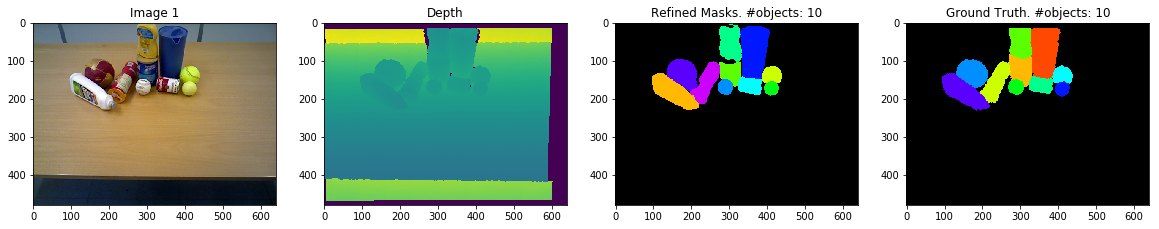

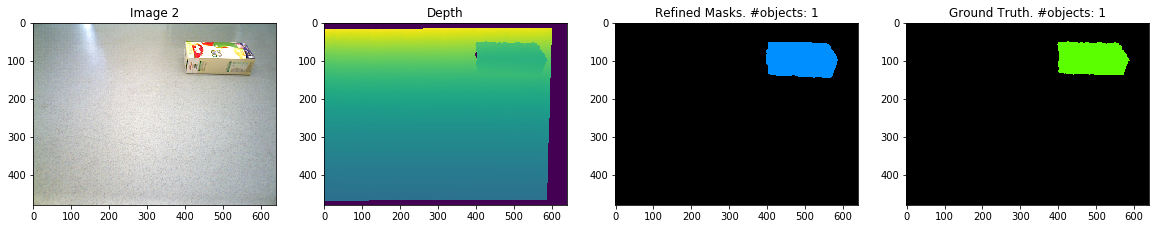

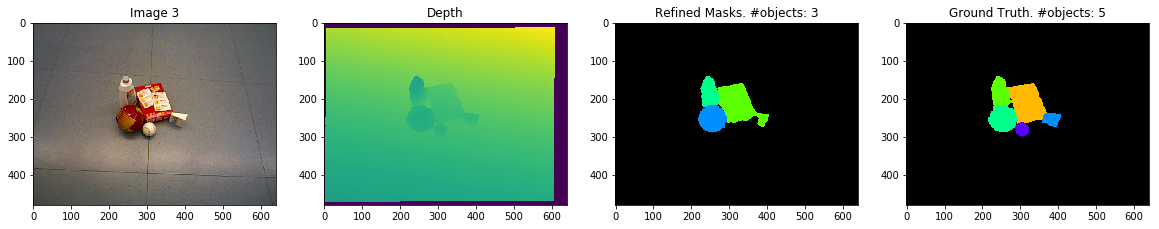

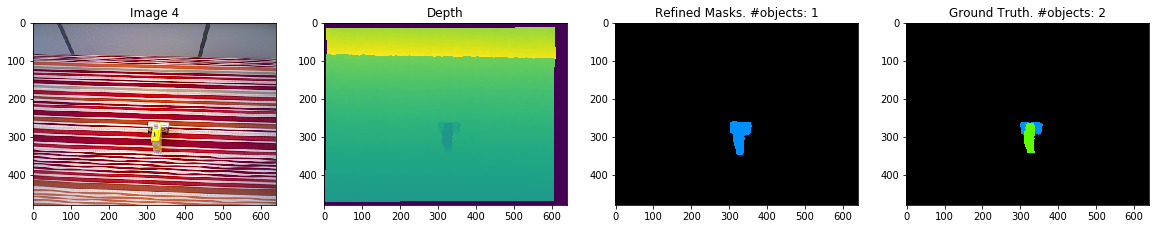

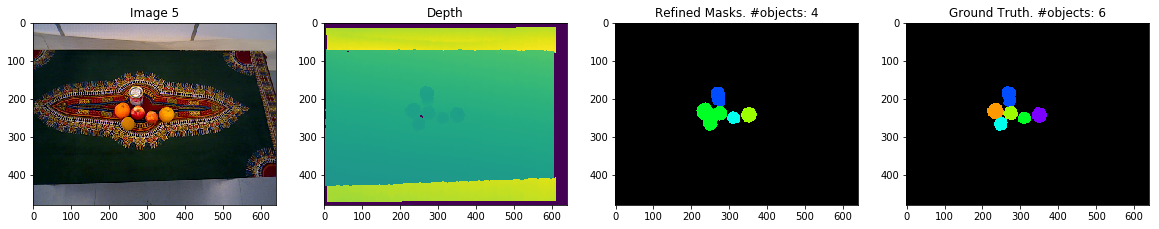

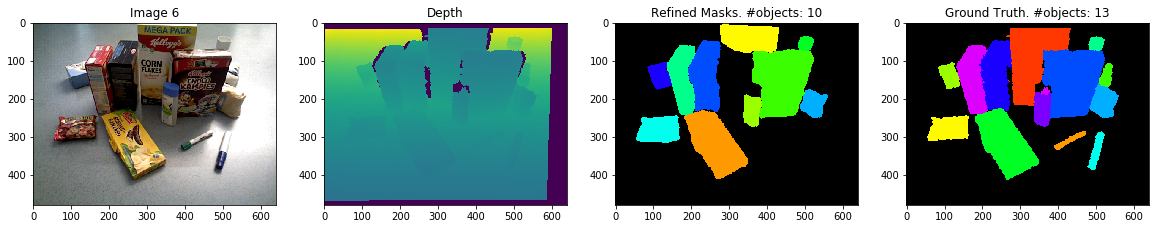

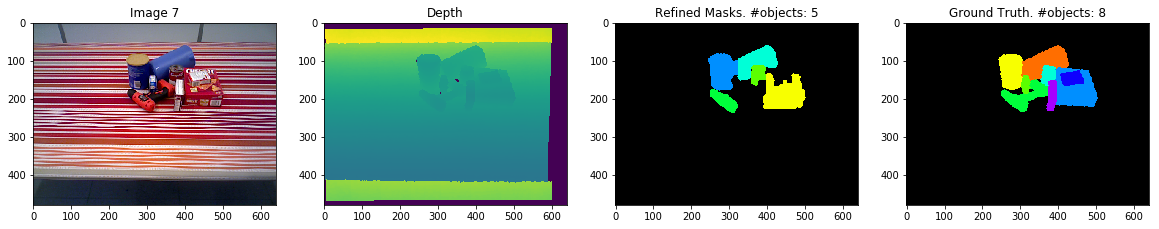

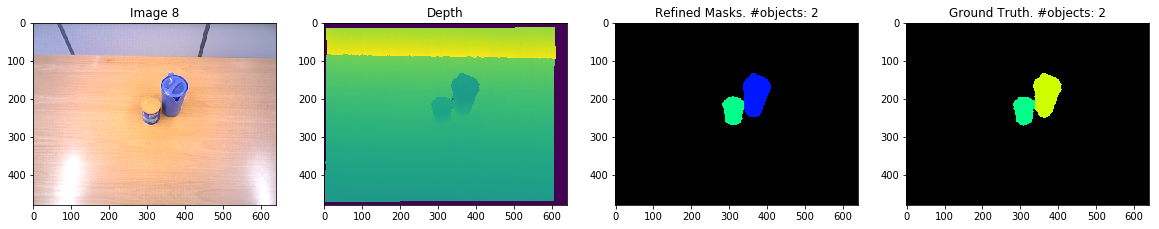

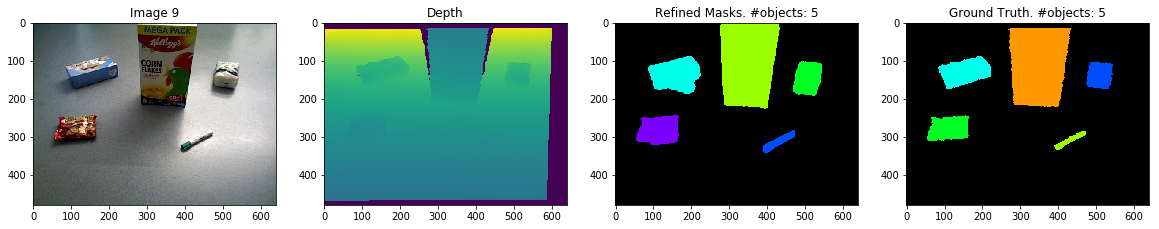

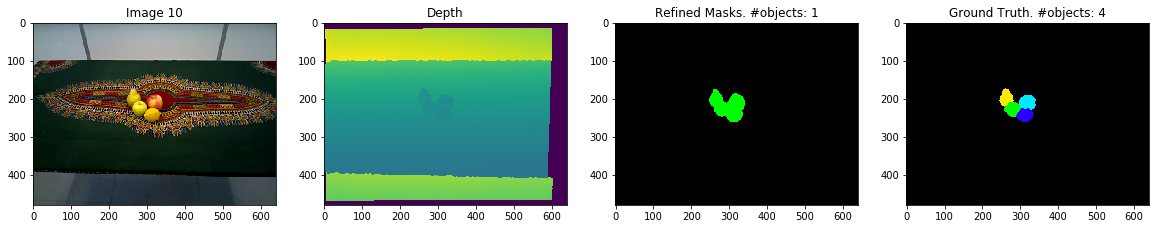

In [21]:
rgb_imgs = torch_to_numpy(batch['rgb'].cpu(), is_standardized_image=True)
xyz_imgs = torch_to_numpy(batch['xyz'].cpu())
total_subplots = 6

fig_index = 1
for i in range(N):
    
    num_objs = max(np.unique(seg_masks[i,...]).max(), np.unique(label_imgs[i,...]).max()) + 1
    
    rgb = rgb_imgs[i].astype(np.uint8)
    depth = xyz_imgs[i,...,2]
    seg_mask_plot = util_.get_color_mask(seg_masks[i,...], nc=num_objs)
    gt_masks = util_.get_color_mask(label_imgs[i,...], nc=num_objs)
    
    images = [rgb, depth, seg_mask_plot, gt_masks]
    titles = [f'Image {i+1}', 'Depth',
              f"Refined Masks. #objects: {np.unique(seg_masks[i,...]).shape[0]-1}",
              f"Ground Truth. #objects: {np.unique(label_imgs[i,...]).shape[0]-1}"
             ]
    util__.subplotter(images, titles, fig_num=i+1)
    
    # Run evaluation metric
    eval_metrics = evaluation.multilabel_metrics(seg_masks[i,...], label_imgs[i])
    print(f"Image {i+1} Metrics:")
    print(eval_metrics)